In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load cleaned cryptocurrency price data
cleaned_data_path = '../data/cleaned/crypto_dataset_cleaned.csv'
df = pd.read_csv(cleaned_data_path)

# Convert 'Date' to datetime and set as index for time series processing
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Load the four representative coins selected from clustering
rep_df = pd.read_csv('../data/processed/representative_coins.csv')
rep_coins = rep_df['Representative_Coin'].tolist()


In [2]:
#Summary Statistics for All Representatives
def summary_statistics(data, coin):
    """Print descriptive statistics of closing prices for a given coin."""
    print(f"\nSummary Statistics for {coin}:")
    print(data[coin].describe())

# Run for all representative coins
for coin in rep_coins:
    summary_statistics(df, coin)


Summary Statistics for STETH-USD:
count     365.000000
mean     2688.761576
std       579.242731
min      1470.473511
25%      2395.390625
50%      2608.588379
75%      3201.034424
max      4006.650146
Name: STETH-USD, dtype: float64

Summary Statistics for BTC-USD:
count       365.000000
mean      84046.393440
std       17523.660666
min       53948.753906
25%       65635.304688
50%       87250.429688
75%       98314.960938
max      111673.281250
Name: BTC-USD, dtype: float64

Summary Statistics for LINK-USD:
count    365.000000
mean      15.195366
std        4.296716
min        9.485442
25%       12.062475
50%       13.850794
75%       17.394213
max       25.291143
Name: LINK-USD, dtype: float64

Summary Statistics for BCH-USD:
count    365.000000
mean     384.990130
std       65.470878
min      268.966736
25%      331.857666
50%      365.255219
75%      432.611206
max      553.742920
Name: BCH-USD, dtype: float64


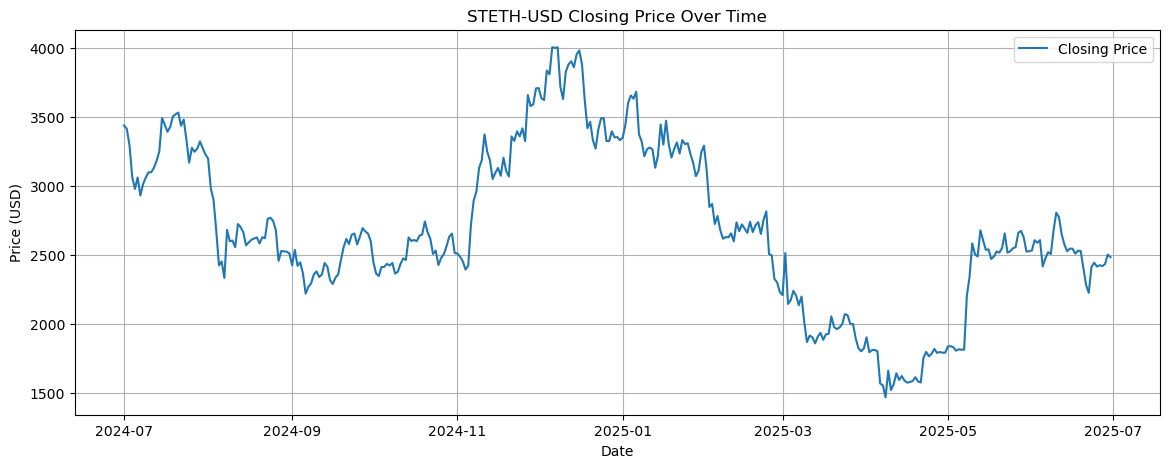

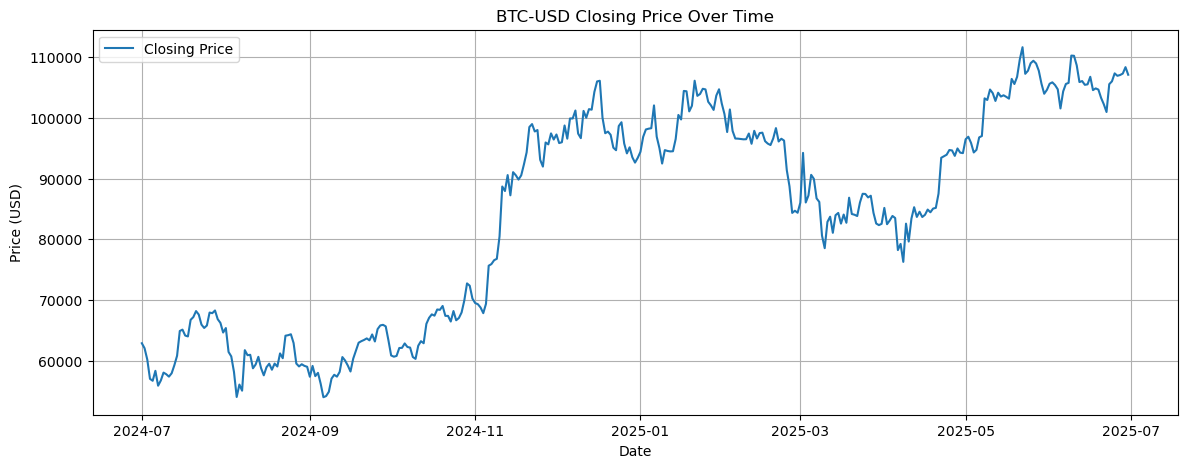

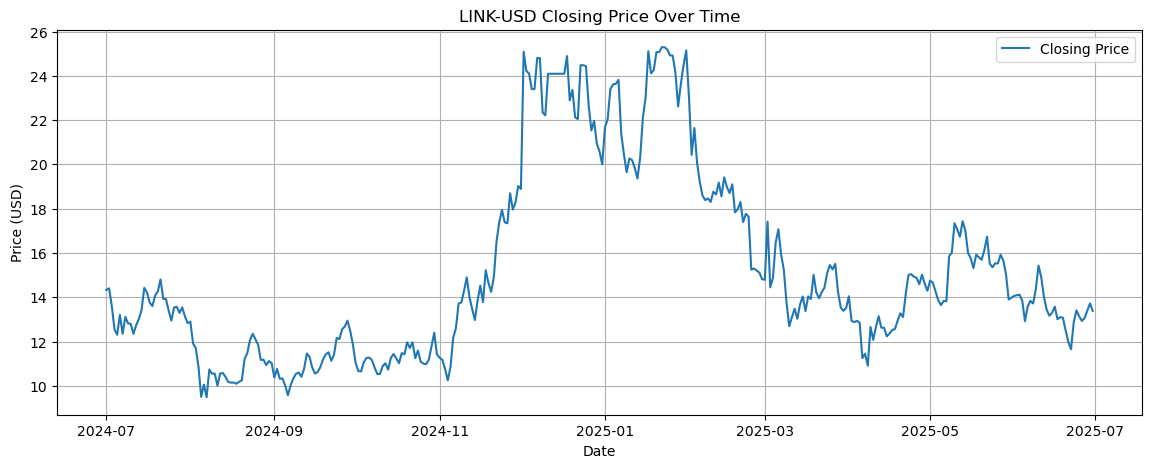

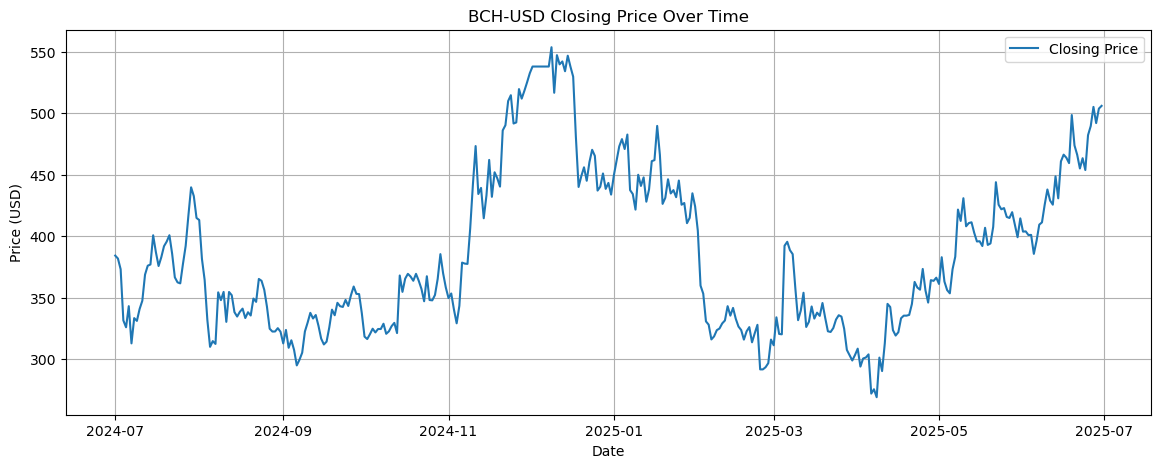

In [3]:
#Closing Price Trend Plot for All Representatives
def plot_price_trend(data, coin):
    """Plot closing price over time to explore temporal trends."""
    plt.figure(figsize=(14, 5))
    plt.plot(data.index, data[coin], label='Closing Price')
    plt.title(f"{coin} Closing Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.grid(True)
    plt.legend()
    plt.show()

# Run for all representative coins
for coin in rep_coins:
    plot_price_trend(df, coin)


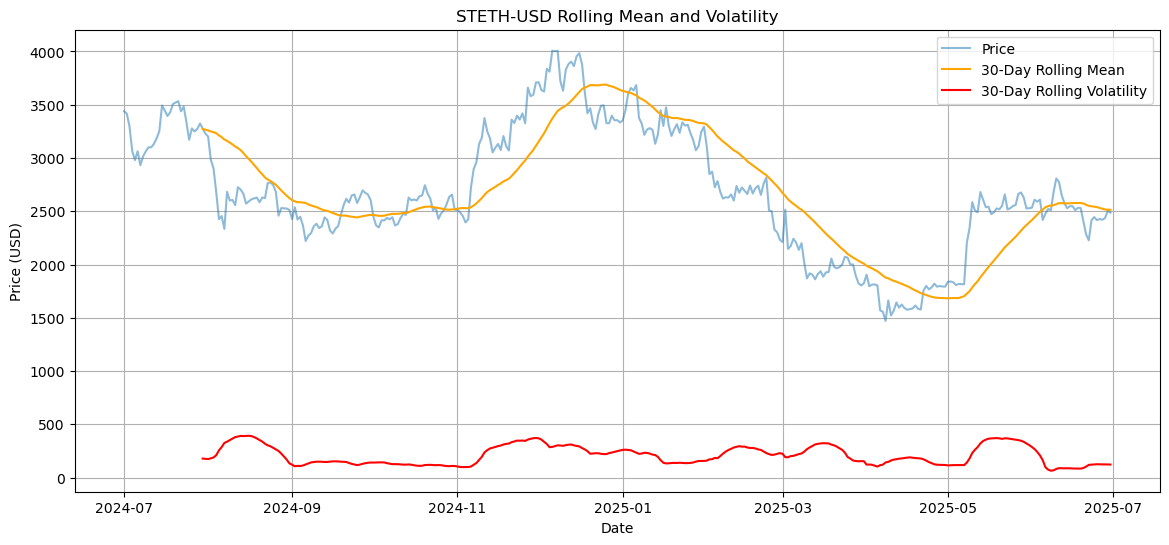

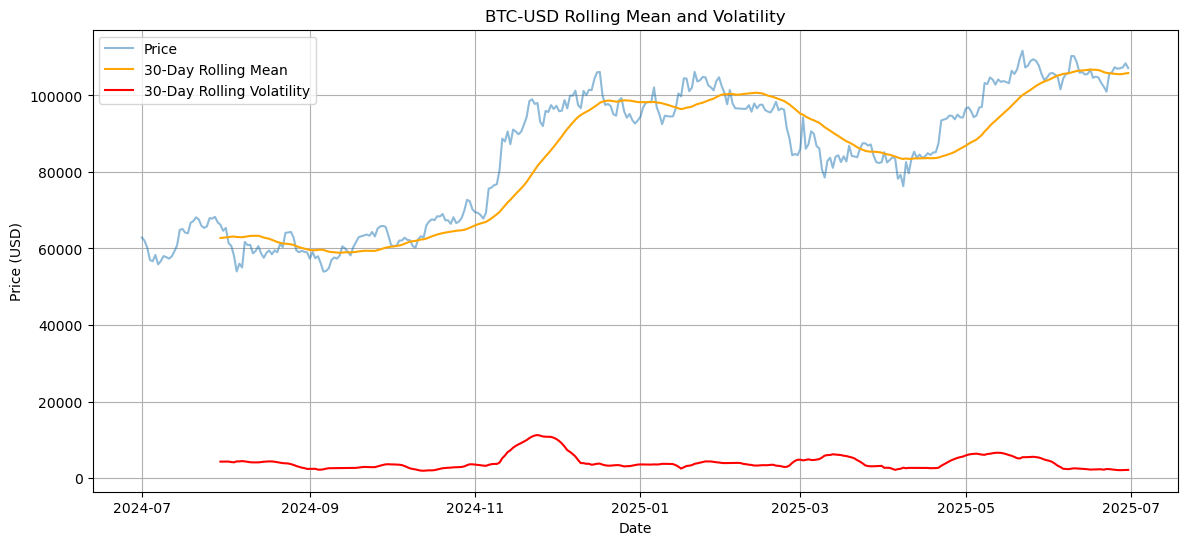

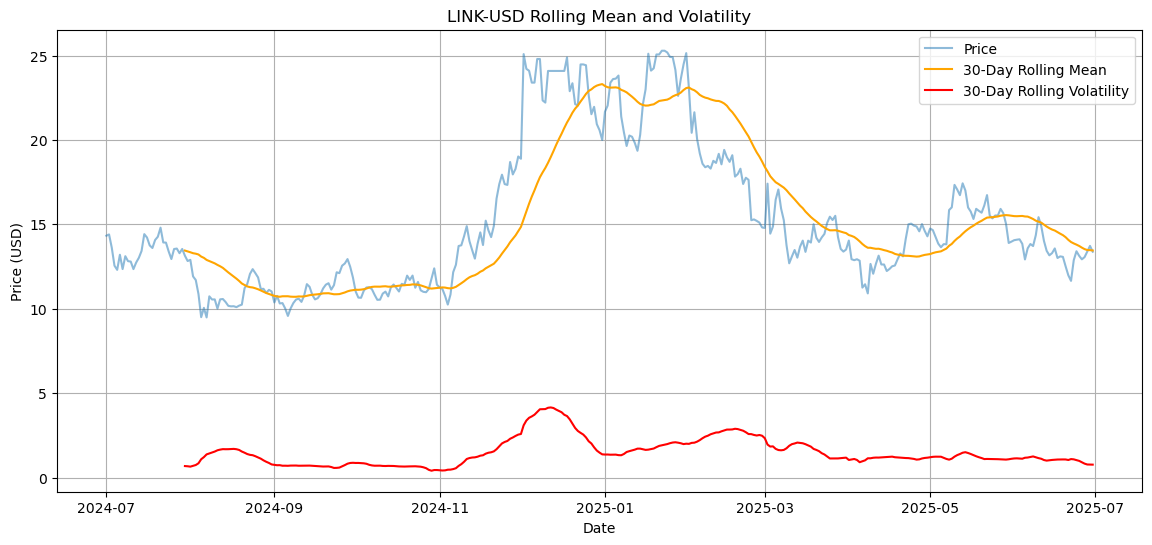

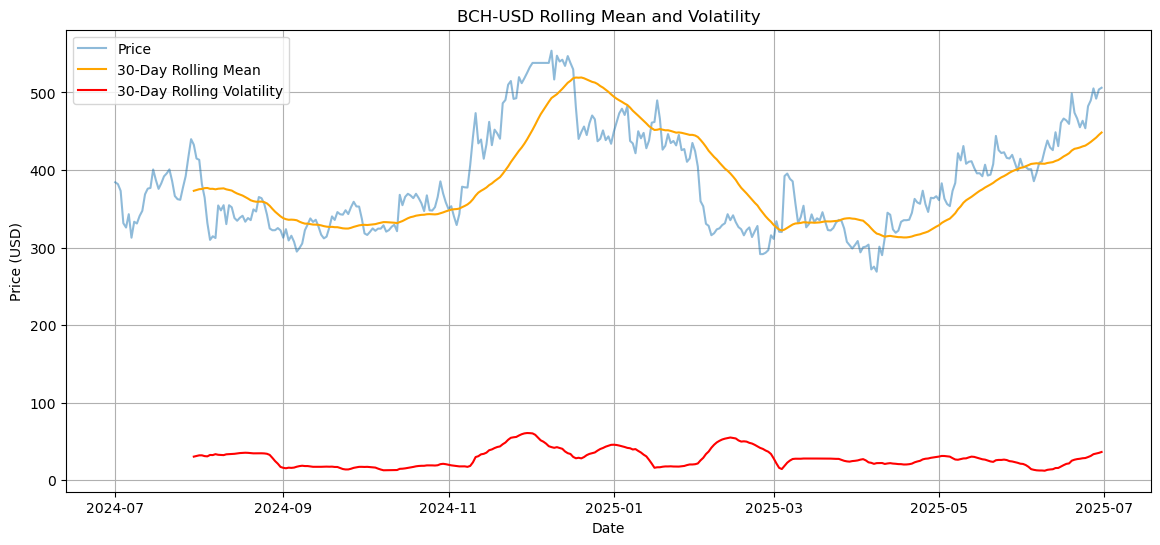

In [4]:
#Rolling Mean and Volatility Plot for All Representatives
def plot_rolling_stats(data, coin, window=30):
    """Plot rolling mean and standard deviation (volatility) over the window."""
    rolling_mean = data[coin].rolling(window=window).mean()
    rolling_std = data[coin].rolling(window=window).std()

    plt.figure(figsize=(14, 6))
    plt.plot(data.index, data[coin], alpha=0.5, label='Price')
    plt.plot(rolling_mean.index, rolling_mean, label=f'{window}-Day Rolling Mean', color='orange')
    plt.plot(rolling_std.index, rolling_std, label=f'{window}-Day Rolling Volatility', color='red')
    plt.title(f"{coin} Rolling Mean and Volatility")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.grid(True)
    plt.show()

# Run for all representative coins
for coin in rep_coins:
    plot_rolling_stats(df, coin)


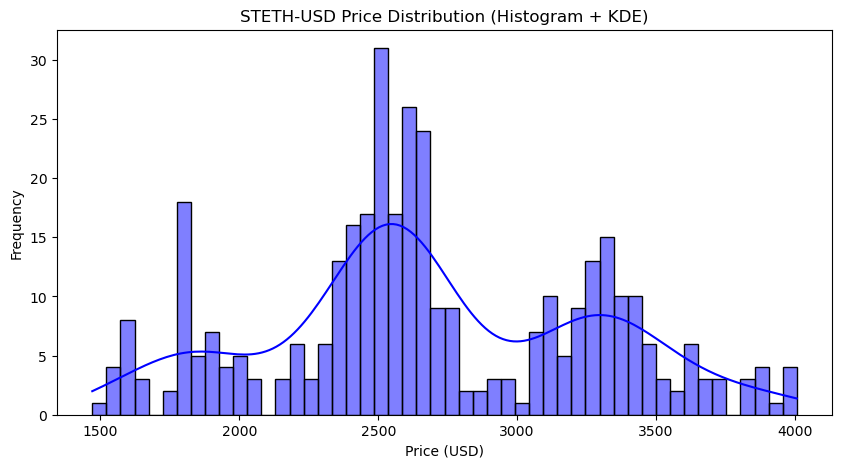

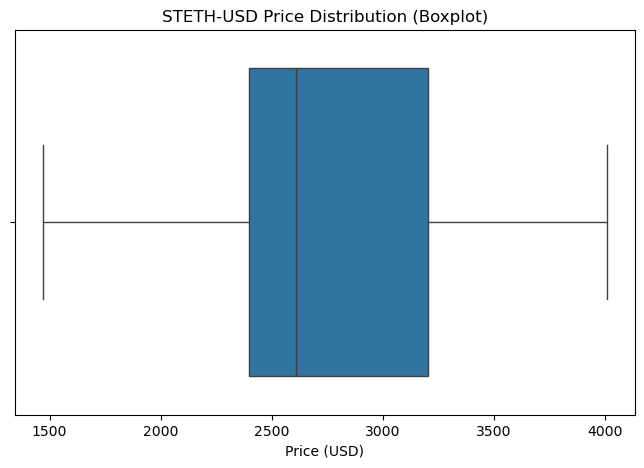

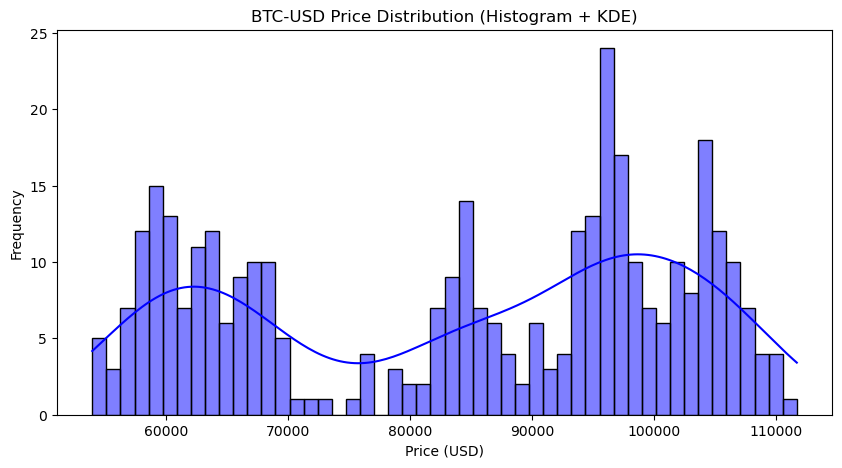

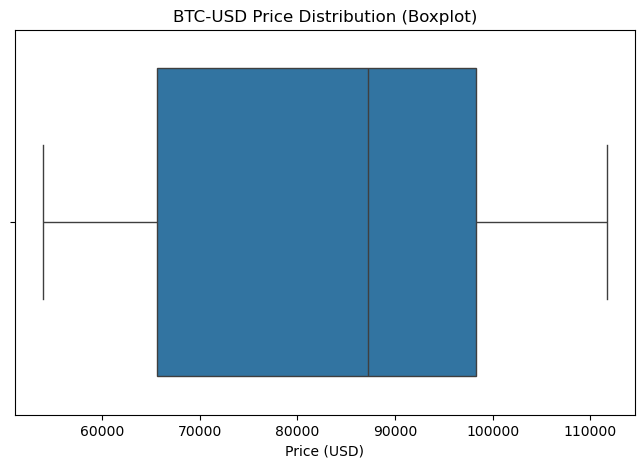

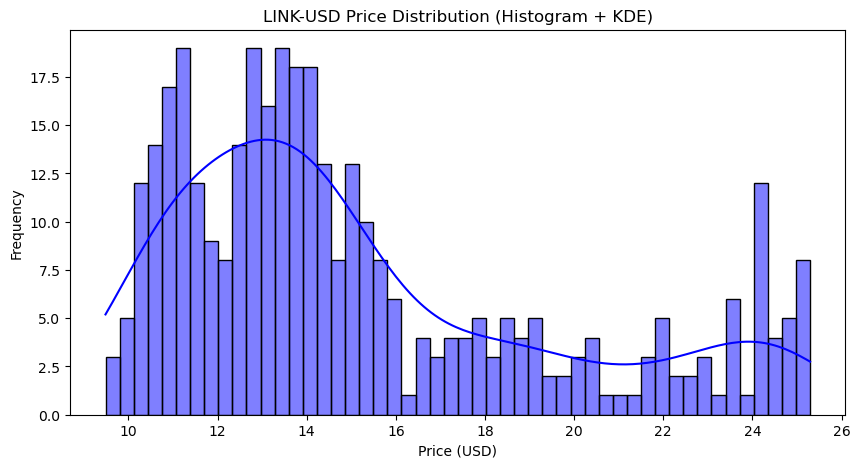

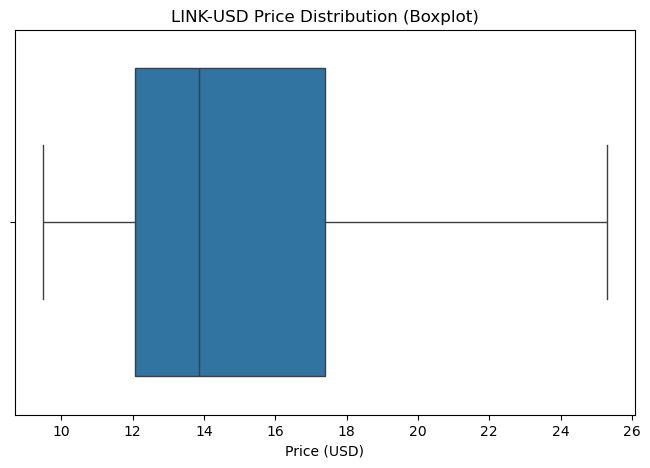

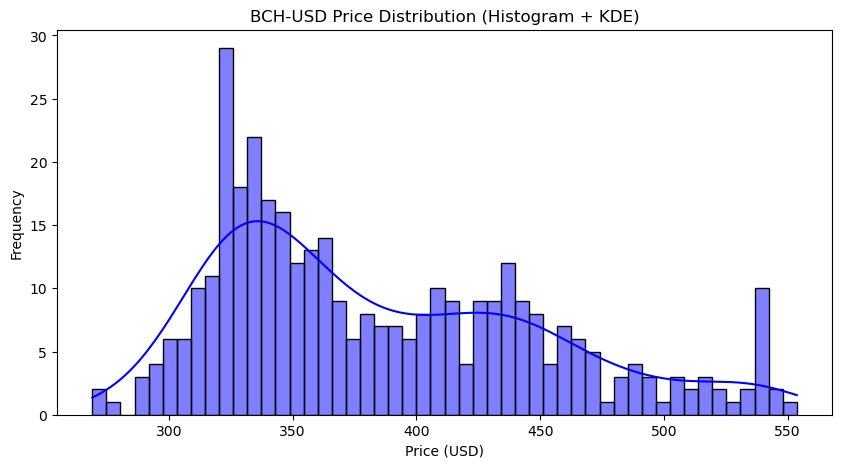

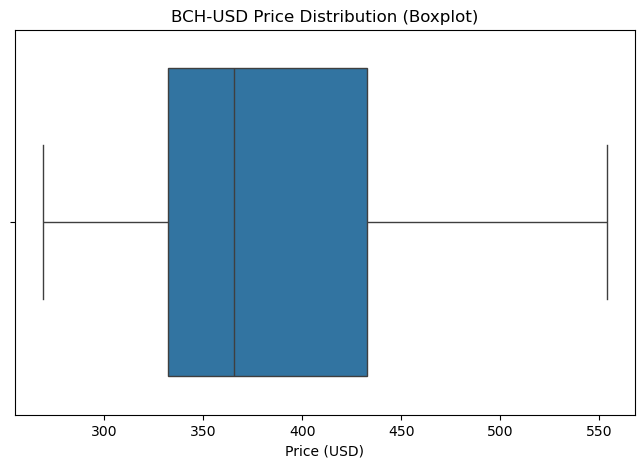

In [5]:
#Price Distribution Plot (Histogram + Boxplot) for All Representatives
def plot_distribution(data, coin):
    """Visualize price distribution with a histogram + KDE and boxplot for outliers."""
    plt.figure(figsize=(10, 5))
    sns.histplot(data[coin], bins=50, kde=True, color='blue')
    plt.title(f"{coin} Price Distribution (Histogram + KDE)")
    plt.xlabel("Price (USD)")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.boxplot(x=data[coin])
    plt.title(f"{coin} Price Distribution (Boxplot)")
    plt.xlabel("Price (USD)")
    plt.show()

# Run for all representative coins
for coin in rep_coins:
    plot_distribution(df, coin)


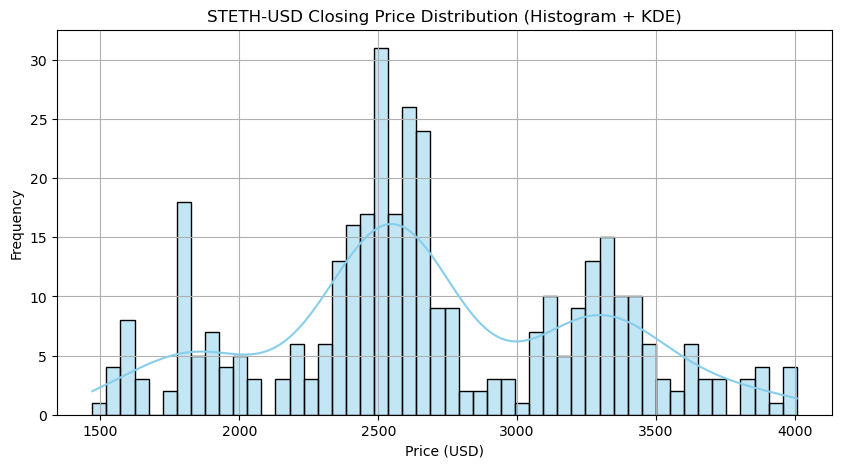

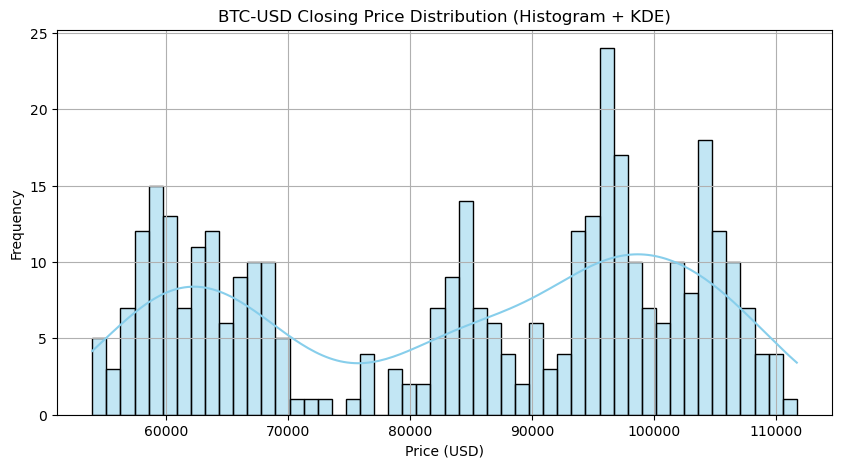

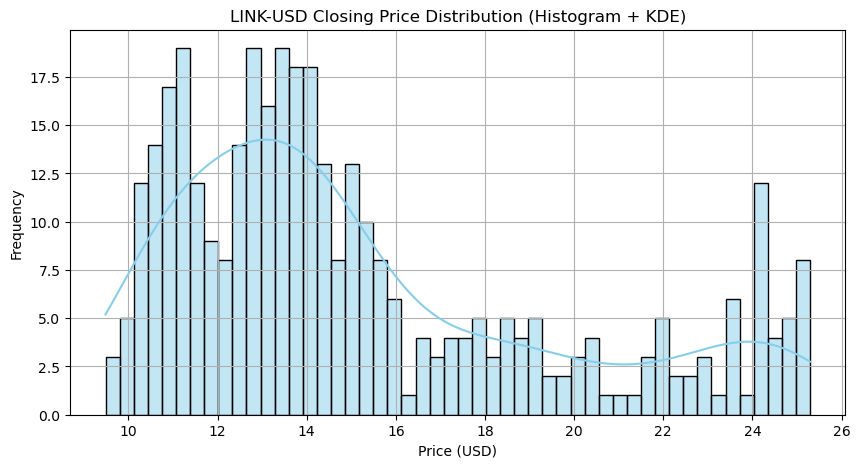

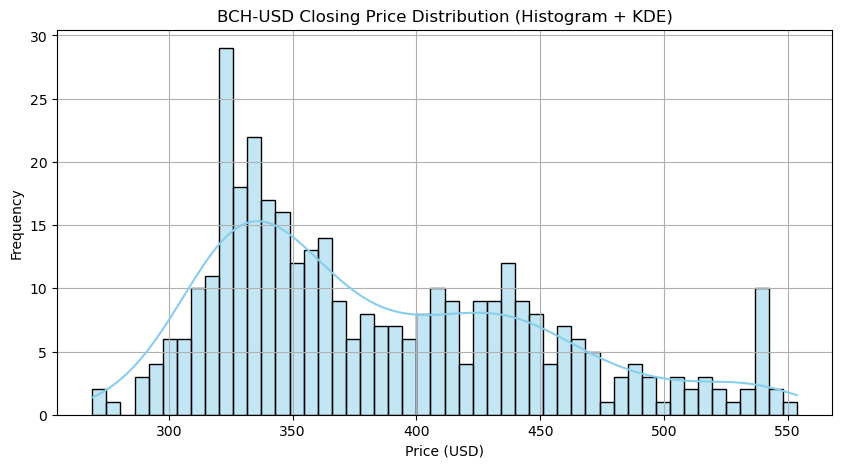

In [6]:
#Closing Price Histogram (with KDE) 
def plot_closing_price_histogram(data, coin):
    """
    Plot histogram with KDE of closing prices to understand distribution of price observations.
    """
    plt.figure(figsize=(10, 5))
    sns.histplot(data[coin], bins=50, kde=True, color='skyblue')
    plt.title(f"{coin} Closing Price Distribution (Histogram + KDE)")
    plt.xlabel("Price (USD)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# Run for all four representative coins
for coin in rep_coins:
    plot_closing_price_histogram(df, coin)


/var/folders/rs/5fvy4hss7cvgk5msj3vhn6t80000gn/T/ipykernel_67832/3607879918.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  returns = data[coin].resample(freq).ffill().pct_change().dropna()


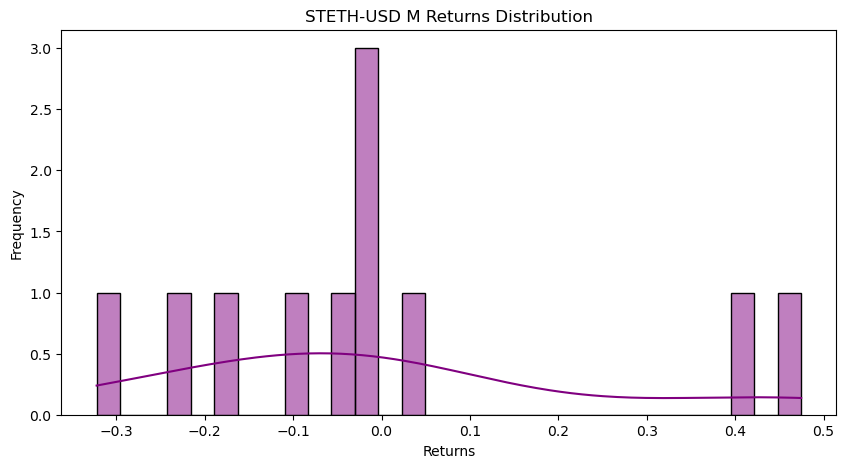

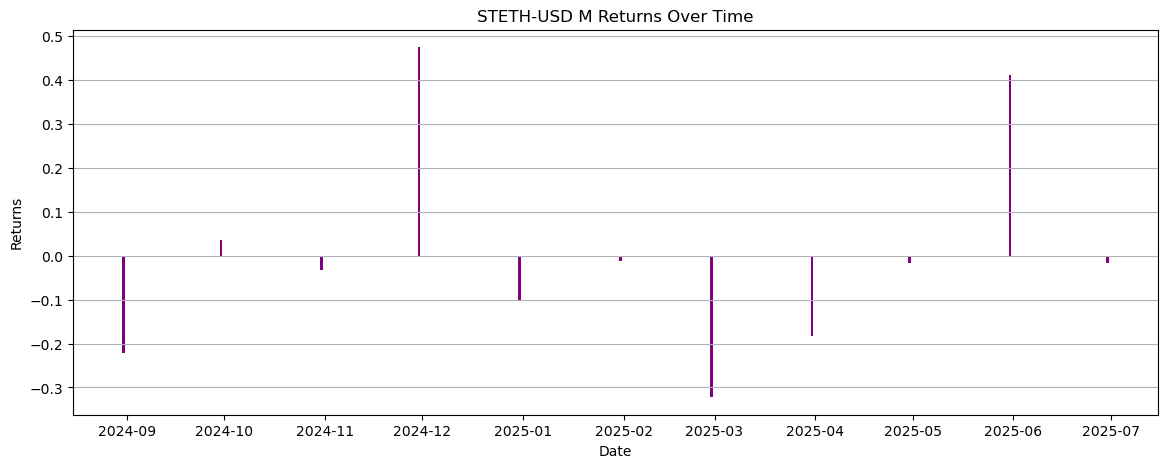

/var/folders/rs/5fvy4hss7cvgk5msj3vhn6t80000gn/T/ipykernel_67832/3607879918.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  returns = data[coin].resample(freq).ffill().pct_change().dropna()


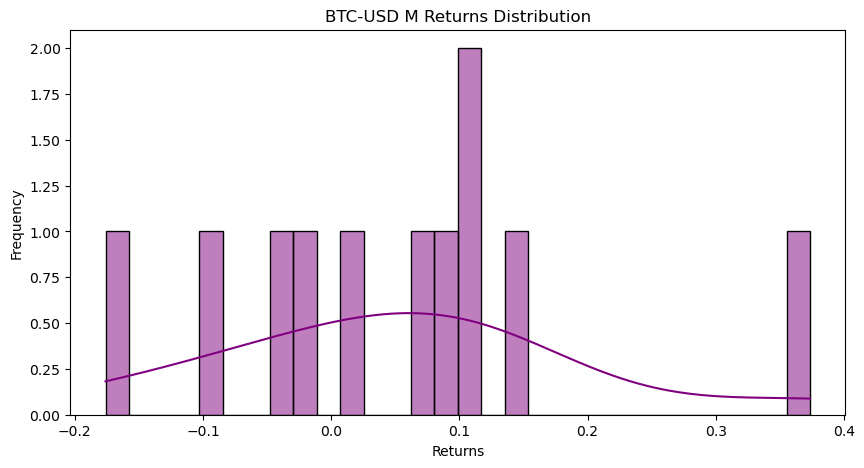

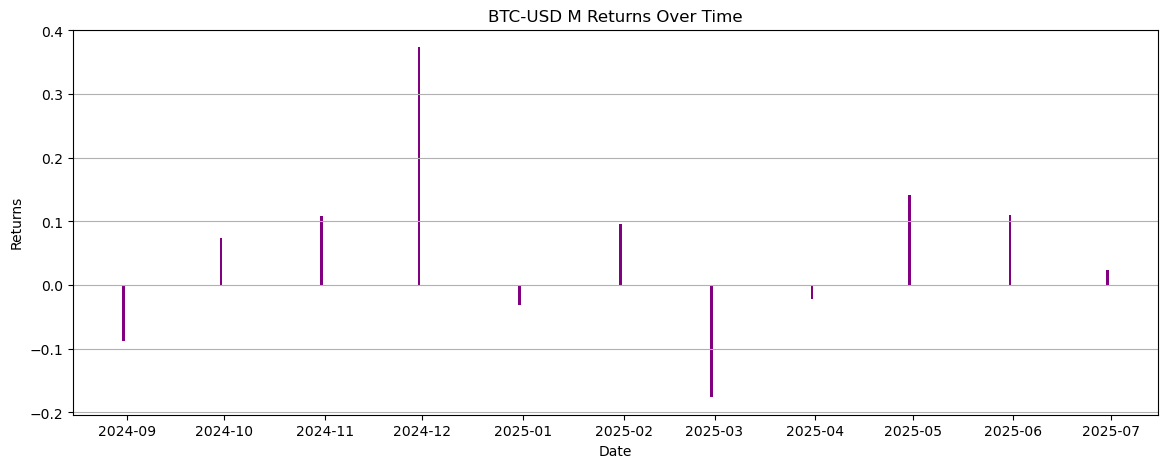

/var/folders/rs/5fvy4hss7cvgk5msj3vhn6t80000gn/T/ipykernel_67832/3607879918.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  returns = data[coin].resample(freq).ffill().pct_change().dropna()


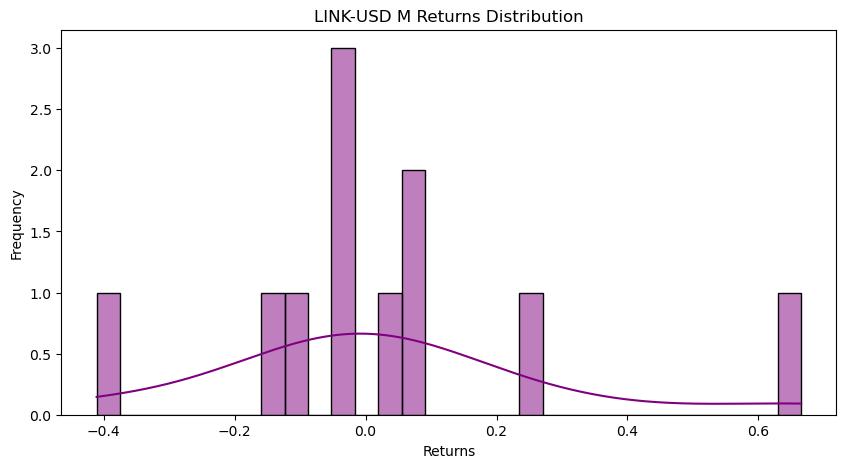

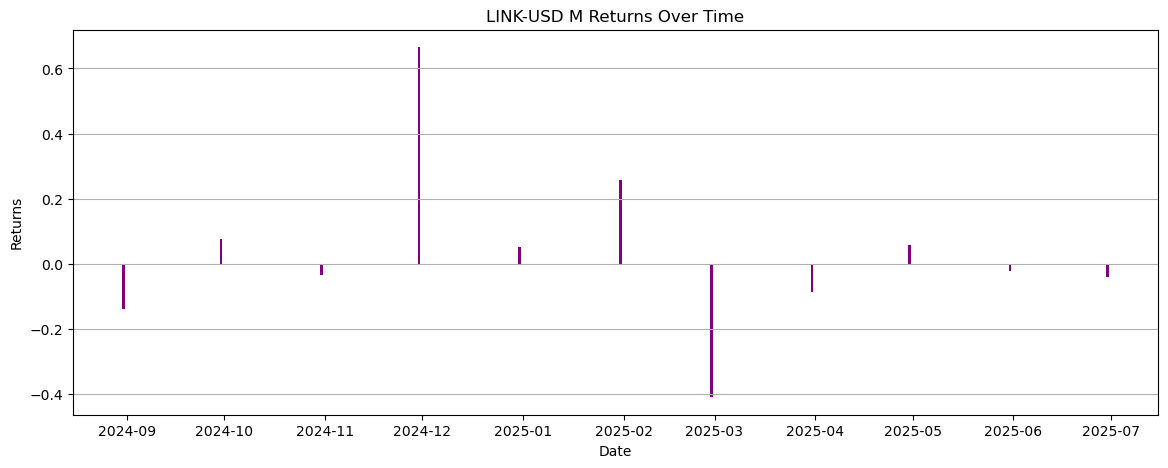

/var/folders/rs/5fvy4hss7cvgk5msj3vhn6t80000gn/T/ipykernel_67832/3607879918.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  returns = data[coin].resample(freq).ffill().pct_change().dropna()


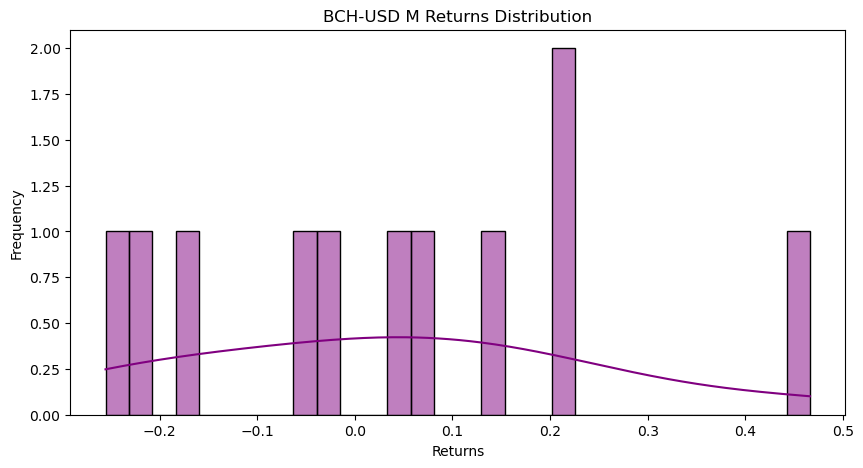

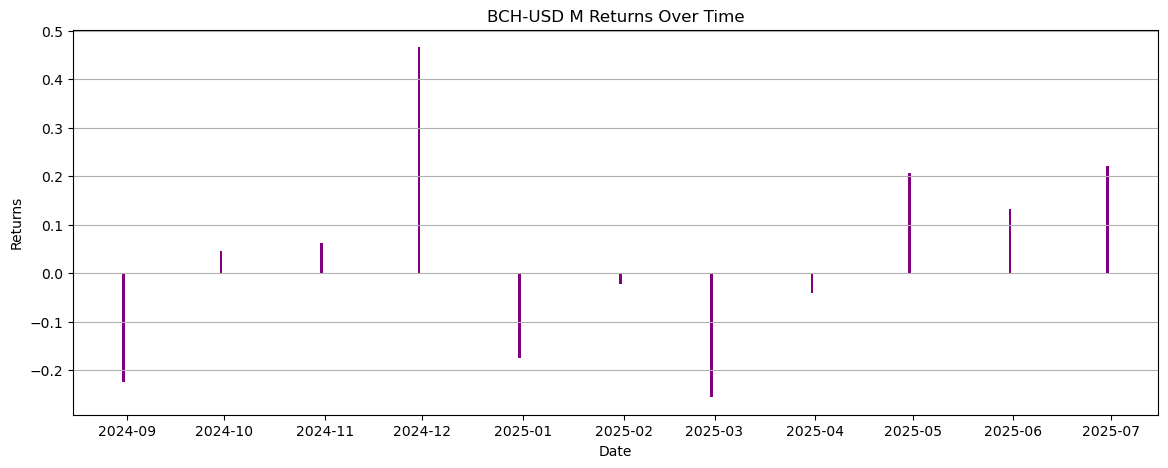

In [7]:
#Monthly Returns Distribution and Return Over Time for All Representatives
def plot_returns_distribution(data, coin, freq='M'):
    """
    Calculate returns over the frequency (monthly 'M' by default),
    plot distribution and returns over time.
    """
    returns = data[coin].resample(freq).ffill().pct_change().dropna()

    plt.figure(figsize=(10, 5))
    sns.histplot(returns, bins=30, kde=True, color='purple')
    plt.title(f"{coin} {freq} Returns Distribution")
    plt.xlabel("Returns")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.bar(returns.index, returns.values, color='purple')
    plt.title(f"{coin} {freq} Returns Over Time")
    plt.xlabel("Date")
    plt.ylabel("Returns")
    plt.grid(axis='y')
    plt.show()

# Run for all representative coins
for coin in rep_coins:
    plot_returns_distribution(df, coin, freq='M')


<Figure size 1400x600 with 0 Axes>

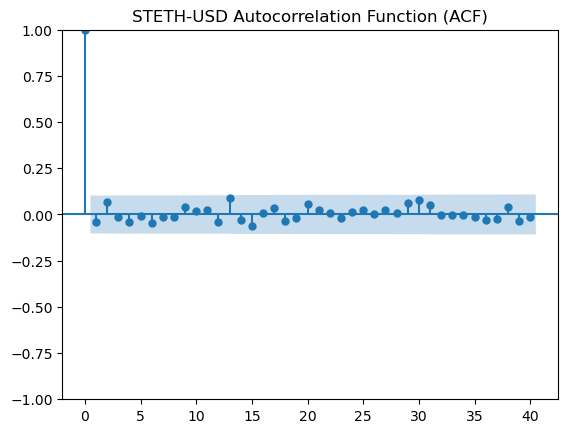

<Figure size 1400x600 with 0 Axes>

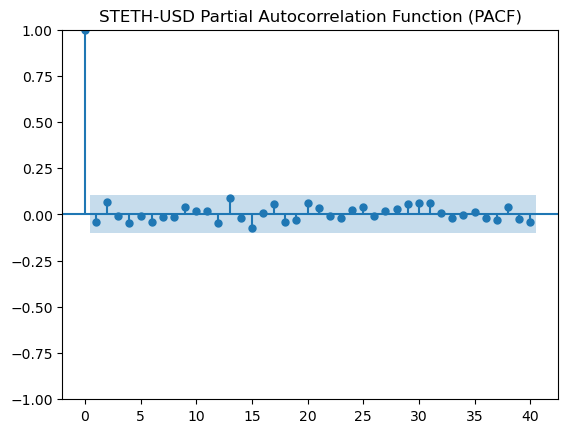

<Figure size 1400x600 with 0 Axes>

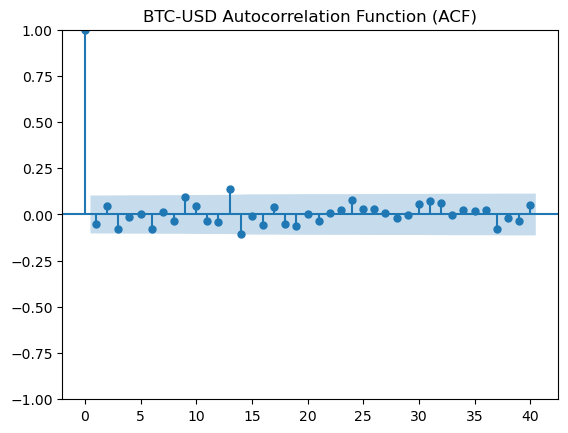

<Figure size 1400x600 with 0 Axes>

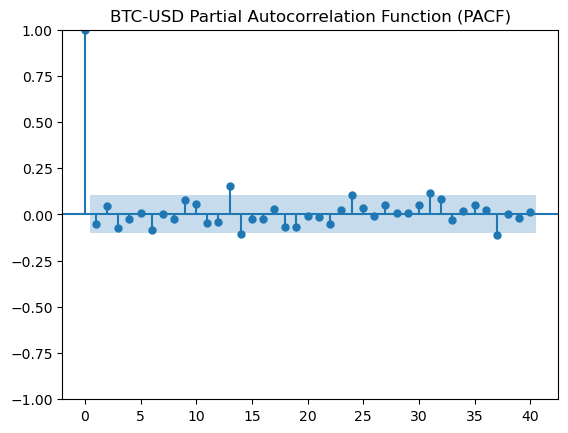

<Figure size 1400x600 with 0 Axes>

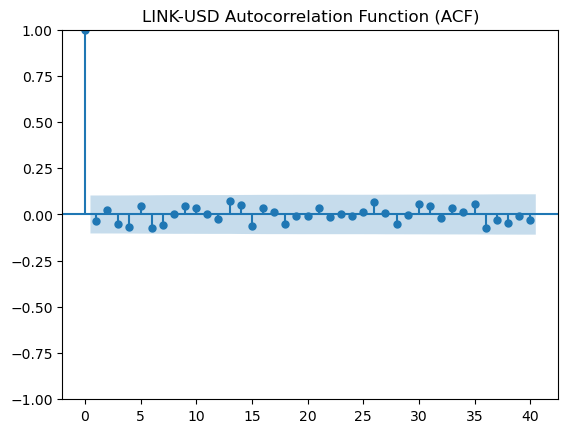

<Figure size 1400x600 with 0 Axes>

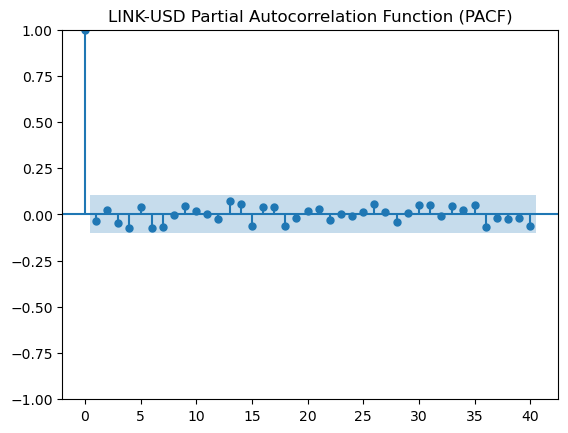

<Figure size 1400x600 with 0 Axes>

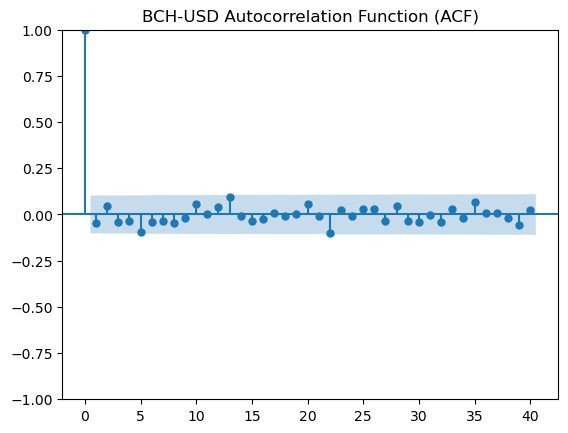

<Figure size 1400x600 with 0 Axes>

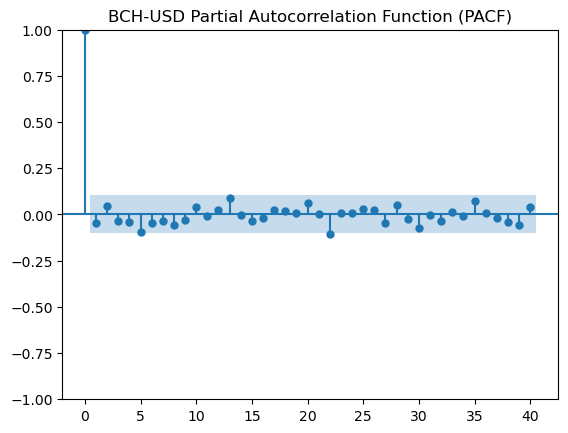

In [8]:
#Autocorrelation and Partial Autocorrelation Plots for All Representatives
def plot_acf_pacf(data, coin, lags=40):
    """
    Plot autocorrelation (ACF) and partial autocorrelation (PACF) of daily returns.
    """
    returns = data[coin].pct_change().dropna()

    plt.figure(figsize=(14, 6))
    plot_acf(returns, lags=lags, alpha=0.05)
    plt.title(f"{coin} Autocorrelation Function (ACF)")
    plt.show()

    plt.figure(figsize=(14, 6))
    plot_pacf(returns, lags=lags, alpha=0.05)
    plt.title(f"{coin} Partial Autocorrelation Function (PACF)")
    plt.show()

# Run for all representative coins
for coin in rep_coins:
    plot_acf_pacf(df, coin)

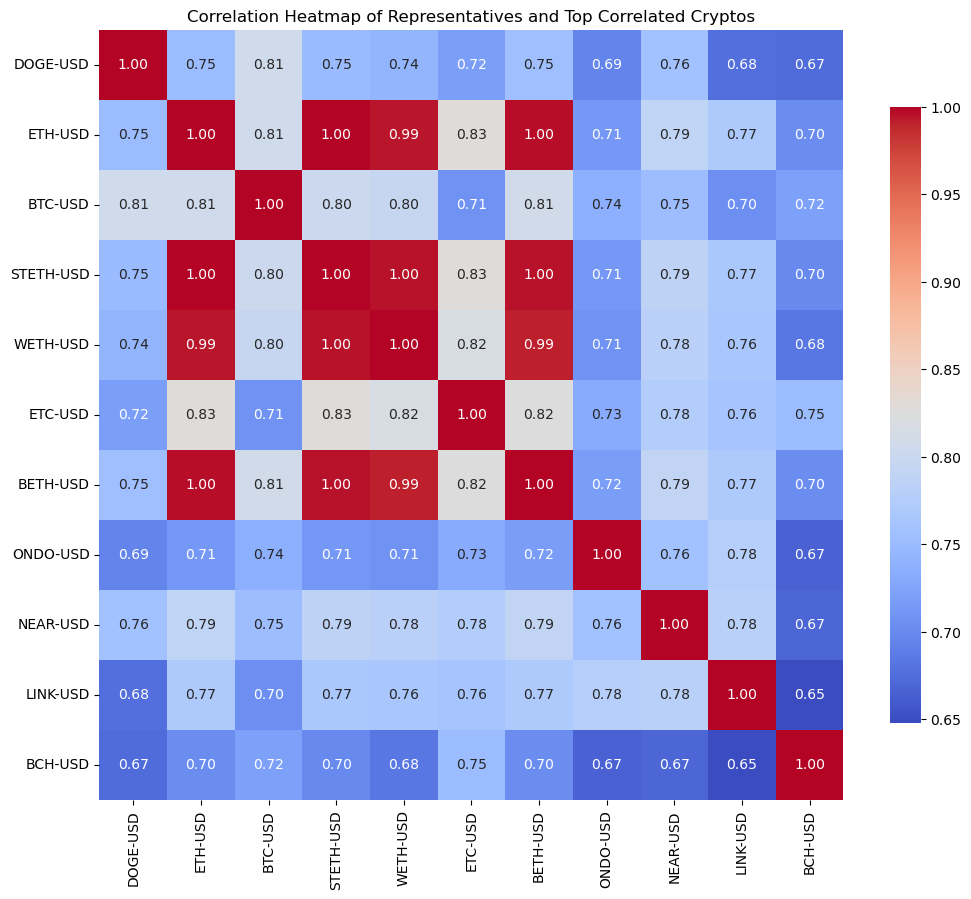

In [9]:
#(Extra Credit): Correlation Heatmap of Returns for Representatives + Top Correlated Coins
def plot_correlation_heatmap(data, rep_coins, top_n=4):
    """
    Plot heatmap of correlations among representative coins and their top correlated coins.
    """
    returns = data.pct_change().dropna()
    corr_matrix = returns.corr()

    selected_coins = set(rep_coins)
    for coin in rep_coins:
        top_corrs = corr_matrix[coin].drop(coin).sort_values(ascending=False).head(top_n).index
        selected_coins.update(top_corrs)

    selected_coins = list(selected_coins)
    sub_corr = corr_matrix.loc[selected_coins, selected_coins]

    plt.figure(figsize=(12, 10))
    sns.heatmap(sub_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={"shrink": .8})
    plt.title("Correlation Heatmap of Representatives and Top Correlated Cryptos")
    plt.show()

# Run once for all representatives
plot_correlation_heatmap(df, rep_coins, top_n=4)


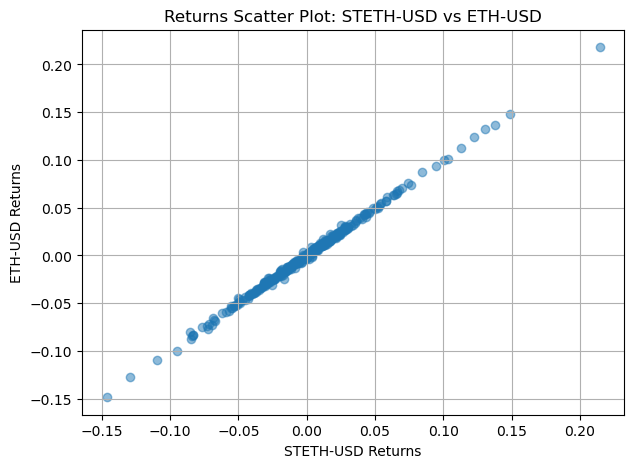

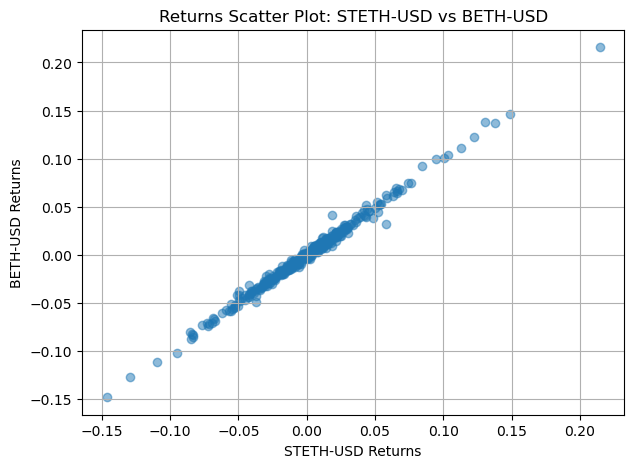

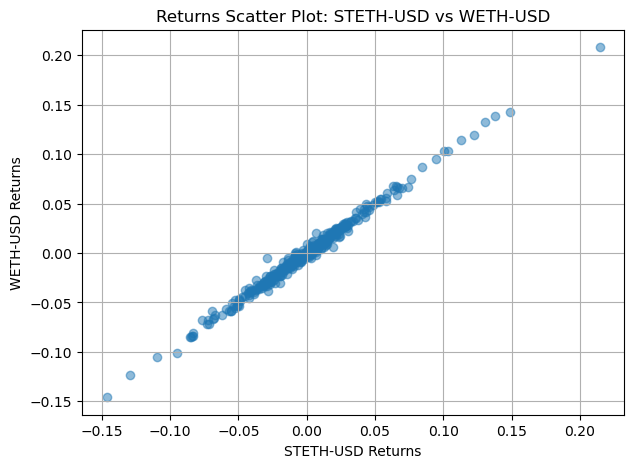

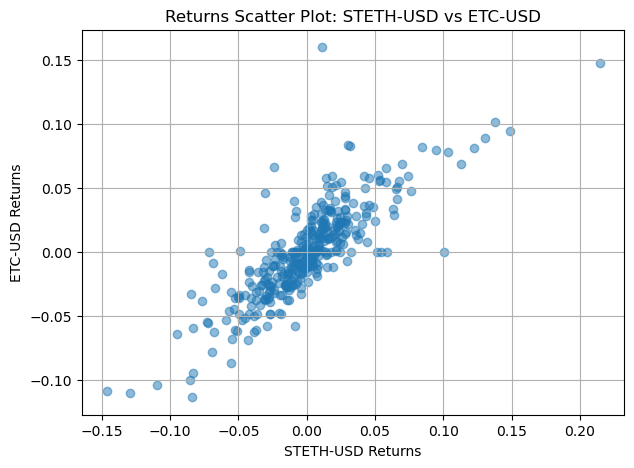

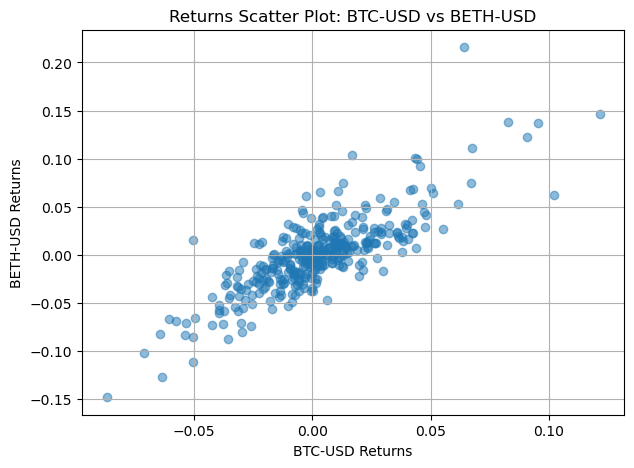

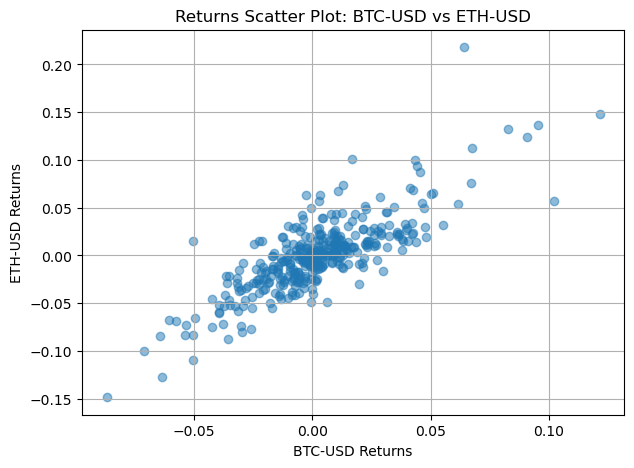

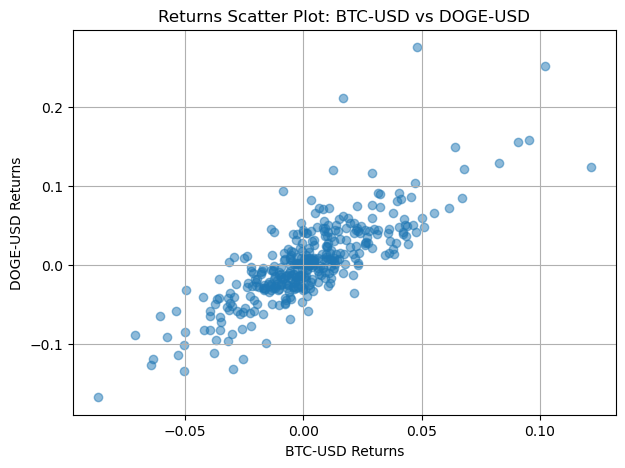

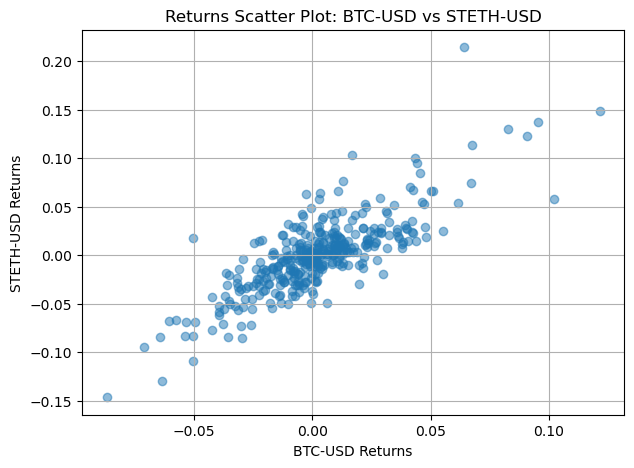

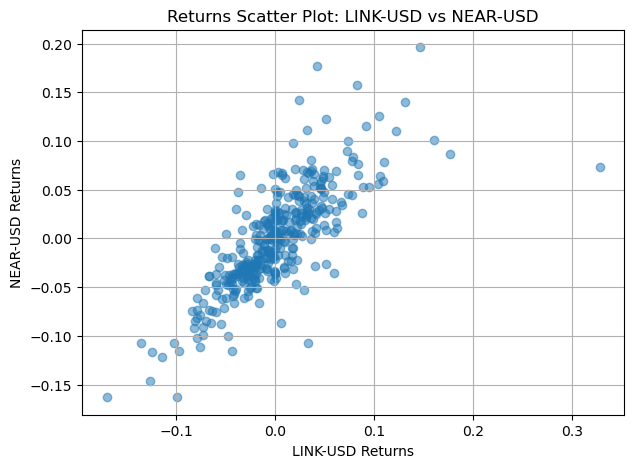

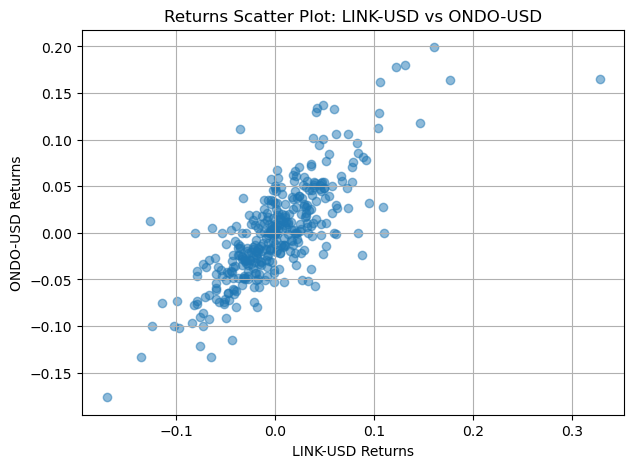

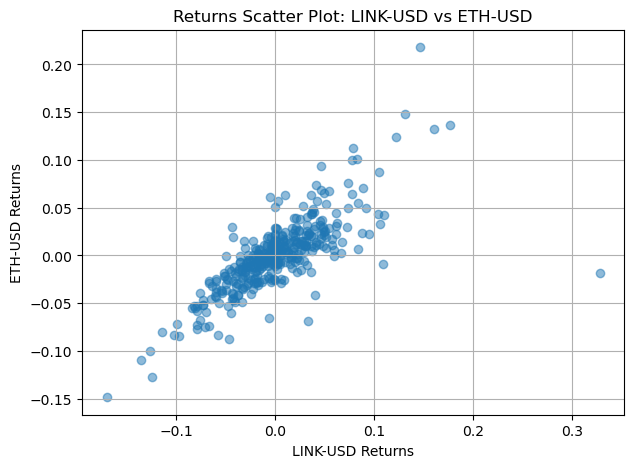

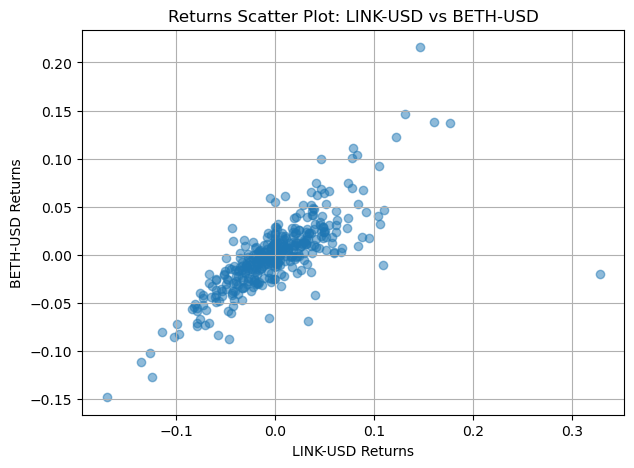

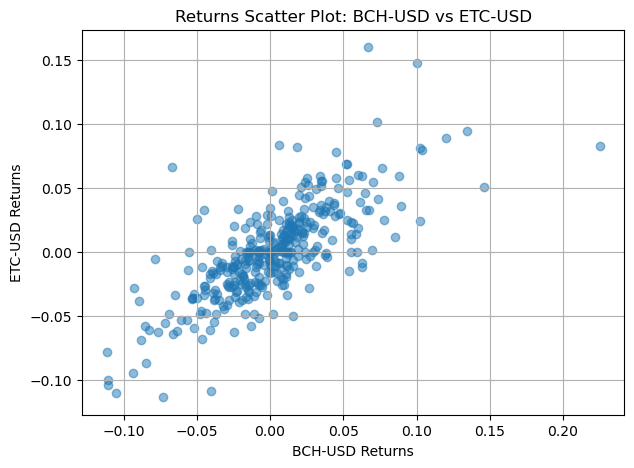

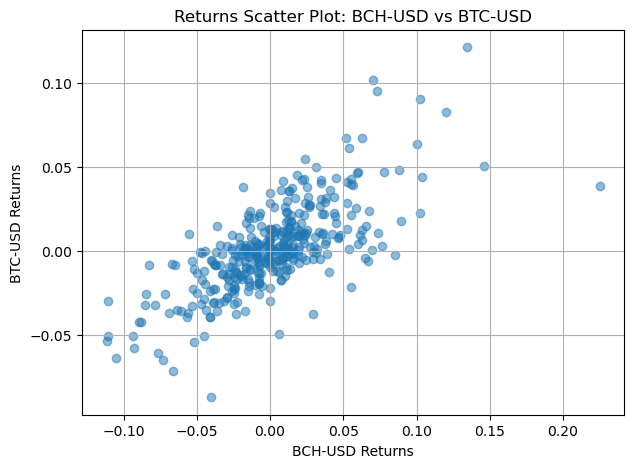

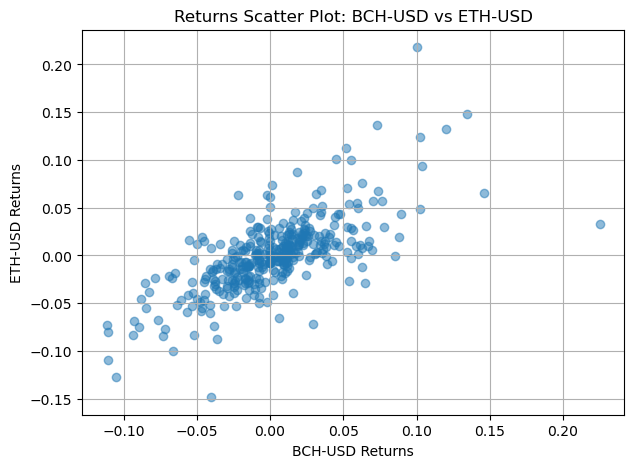

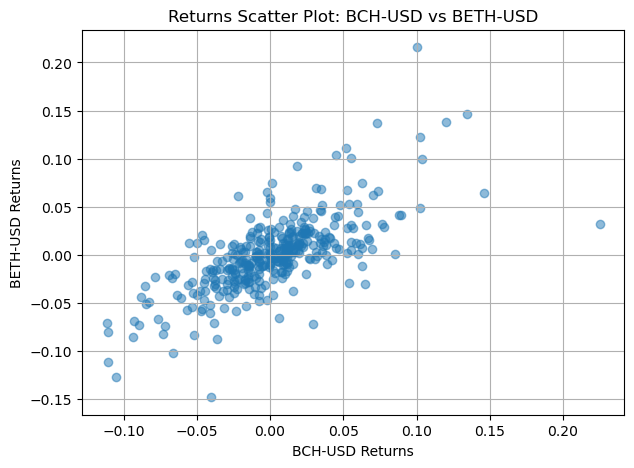

In [10]:
#(Extra Credit): Scatter Plots of Returns for Representatives Vs Top Correlated Coins
def plot_returns_scatter(data, rep_coins, top_n=4):
    """
    Scatter plot returns of representative coins vs their top positively correlated coins.
    """
    returns = data.pct_change().dropna()
    corr_matrix = returns.corr()

    for coin in rep_coins:
        top_corrs = corr_matrix[coin].drop(coin).sort_values(ascending=False).head(top_n).index
        for other_coin in top_corrs:
            plt.figure(figsize=(7,5))
            plt.scatter(returns[coin], returns[other_coin], alpha=0.5)
            plt.title(f'Returns Scatter Plot: {coin} vs {other_coin}')
            plt.xlabel(f'{coin} Returns')
            plt.ylabel(f'{other_coin} Returns')
            plt.grid(True)
            plt.show()

# Run once for all representatives
plot_returns_scatter(df, rep_coins, top_n=4)

Select a cryptocurrency by number:
1. STETH-USD
2. BTC-USD
3. LINK-USD
4. BCH-USD


Enter the number for your selection:  1


Select a cryptocurrency by number:
1. STETH-USD
2. BTC-USD
3. LINK-USD
4. BCH-USD


Enter the number for your selection:  2


Pearson Correlation between STETH-USD and BTC-USD: 0.8017


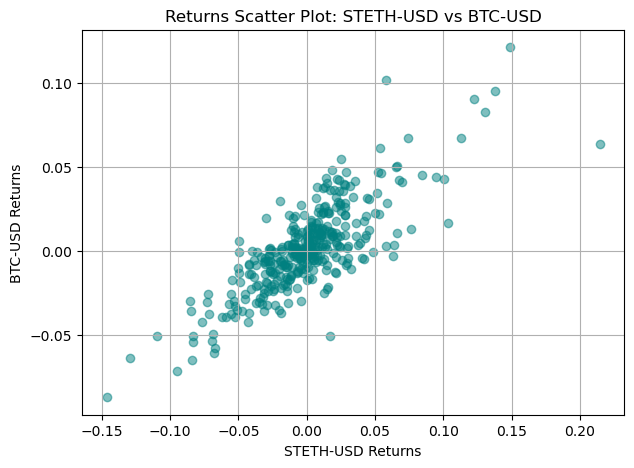

In [11]:
def get_coin_selection(rep_coins):
    """
    Displays the list of coins with numbers and prompts the user to input a number
    to select the coin. Returns the selected coin symbol.
    """
    print("Select a cryptocurrency by number:")
    for i, coin in enumerate(rep_coins, 1):
        print(f"{i}. {coin}")

    while True:
        try:
            selection = int(input("Enter the number for your selection: "))
            if 1 <= selection <= len(rep_coins):
                return rep_coins[selection - 1]
            else:
                print(f"Please enter a number between 1 and {len(rep_coins)}")
        except ValueError:
            print("Invalid input. Please enter a valid number.")

def compute_and_plot_correlation(data, coin1, coin2):
    """
    Computes Pearson correlation between daily returns of two selected coins
    and shows a scatter plot of their returns for visual analysis.
    """
    import matplotlib.pyplot as plt
    returns = data[[coin1, coin2]].pct_change().dropna()
    corr_value = returns[coin1].corr(returns[coin2])
    print(f"Pearson Correlation between {coin1} and {coin2}: {corr_value:.4f}")

    plt.figure(figsize=(7, 5))
    plt.scatter(returns[coin1], returns[coin2], alpha=0.5, color='teal')
    plt.title(f'Returns Scatter Plot: {coin1} vs {coin2}')
    plt.xlabel(f'{coin1} Returns')
    plt.ylabel(f'{coin2} Returns')
    plt.grid(True)
    plt.show()

# Usage example (assuming rep_coins list and df dataframe are already defined):

selected_coin1 = get_coin_selection(rep_coins)
selected_coin2 = get_coin_selection(rep_coins)

compute_and_plot_correlation(df, selected_coin1, selected_coin2)


Select a cryptocurrency by number:
1. STETH-USD
2. BTC-USD
3. LINK-USD
4. BCH-USD


Enter the number for your selection:  1


Select a cryptocurrency by number:
1. STETH-USD
2. BTC-USD
3. LINK-USD
4. BCH-USD


Enter the number for your selection:  3


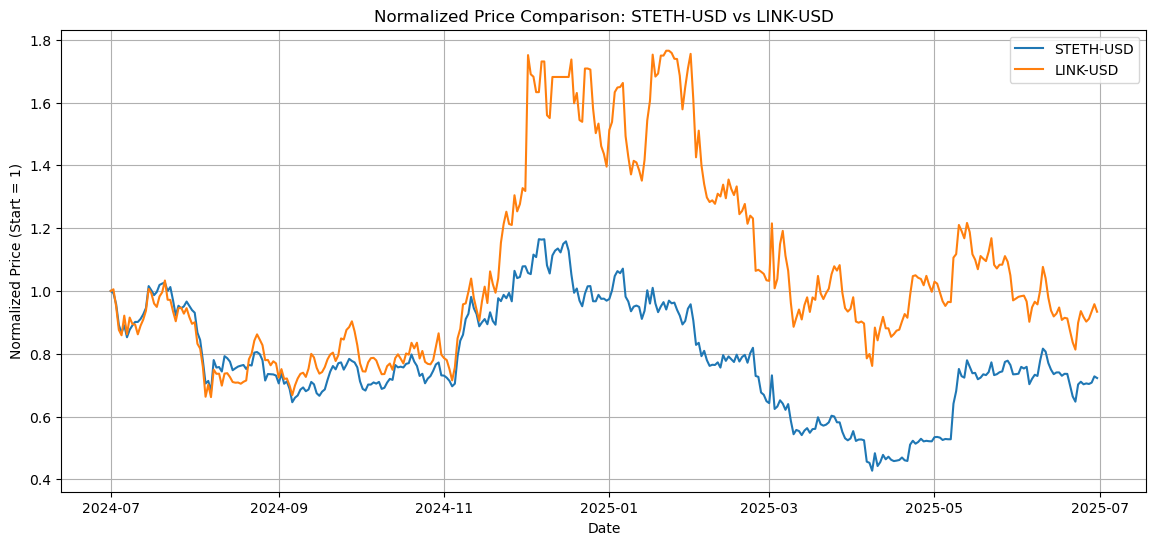

In [30]:
def get_coin_selection(rep_coins):
    """
    Displays the list of representative coins with numbers and lets the user select
    by inputting a number. Returns the selected coin symbol from rep_coins.
    """
    print("Select a cryptocurrency by number:")
    for i, coin in enumerate(rep_coins, 1):
        print(f"{i}. {coin}")

    while True:
        try:
            selection = int(input("Enter the number for your selection: "))
            if 1 <= selection <= len(rep_coins):
                return rep_coins[selection - 1]
            else:
                print(f"Please enter a number between 1 and {len(rep_coins)}")
        except ValueError:
            print("Invalid input. Please enter a valid number.")

def plot_normalized_price_comparison(data, coin1, coin2):
    """
    Plot normalized closing prices of two cryptocurrencies for direct visual comparison.
    Prices are normalized to 1 at the start date to compare relative performance.
    """
    norm_price1 = data[coin1] / data[coin1].iloc[0]
    norm_price2 = data[coin2] / data[coin2].iloc[0]

    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(14, 6))
    plt.plot(norm_price1.index, norm_price1, label=coin1)
    plt.plot(norm_price2.index, norm_price2, label=coin2)
    plt.title(f'Normalized Price Comparison: {coin1} vs {coin2}')
    plt.xlabel('Date')
    plt.ylabel('Normalized Price (Start = 1)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Usage example assuming rep_coins is defined and df is your dataframe:
selected_coin1 = get_coin_selection(rep_coins)
selected_coin2 = get_coin_selection(rep_coins)

plot_normalized_price_comparison(df, selected_coin1, selected_coin2)
